Accuracy Score: 0.8665

Confusion Matrix:
[[1548   59]
 [ 208  185]]


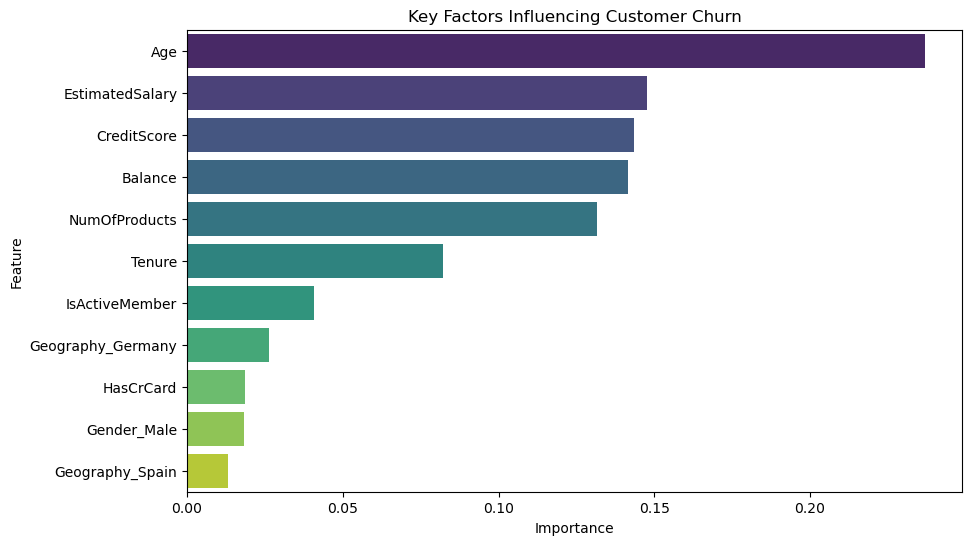


Top 3 Factors Influencing Churn:
           Feature  Importance
1              Age    0.236922
7  EstimatedSalary    0.147558
0      CreditScore    0.143338


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------------------
# 1. LOAD & CLEAN DATASET
# ---------------------------------------------------------
# Load the Churn Modelling dataset
# Replace 'Churn_Modelling.csv' with your local file path
df = pd.read_csv('Churn_Modelling.csv')

# Drop irrelevant columns that don't help with prediction
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# ---------------------------------------------------------
# 2. CATEGORICAL ENCODING
# ---------------------------------------------------------
# Using One-Hot Encoding for Geography and Gender
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# ---------------------------------------------------------
# 3. MODEL TRAINING
# ---------------------------------------------------------
# Defining features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using RandomForest as it is excellent for feature importance analysis
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. EVALUATION & FEATURE IMPORTANCE
# ---------------------------------------------------------
# Predictions
predictions = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, predictions):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# --- FEATURE IMPORTANCE ANALYSIS ---
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Key Factors Influencing Customer Churn')
plt.show()

print("\nTop 3 Factors Influencing Churn:")
print(feature_importance_df.head(3))